In [1]:
import astropy
import lightkurve
import dask
import numpy as np
import matplotlib.pyplot as plt

print(f"Astropy: {astropy.__version__}")
print(f"Lightkurve: {lightkurve.__version__}")
print(f"Dask: {dask.__version__}")
print(f"Numpy: {np.__version__}")
print("All imports successful!")

/home/hrudayraj/miniconda3/envs/astro/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Astropy: 8.0.0
Lightkurve: 2.6.0
Dask: 2024.8.2
Numpy: 2.4.6
All imports successful!


In [2]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

print("Searching TESS archive for TOI-270...")
search_result = lk.search_lightcurve('TOI-270', mission='TESS', author='SPOC')
print(search_result)

Searching TESS archive for TOI-270...
SearchResult containing 11 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 03 2018   SPOC     120   259377017      0.0
  1 TESS Sector 04 2018   SPOC     120   259377017      0.0
  2 TESS Sector 05 2018   SPOC     120   259377017      0.0
  3 TESS Sector 30 2020   SPOC      20   259377017      0.0
  4 TESS Sector 32 2020   SPOC      20   259377017      0.0
  5 TESS Sector 30 2020   SPOC     120   259377017      0.0
  6 TESS Sector 32 2020   SPOC     120   259377017      0.0
  7 TESS Sector 97 2025   SPOC      20   259377017      0.0
  8 TESS Sector 98 2025   SPOC      20   259377017      0.0
  9 TESS Sector 97 2025   SPOC     120   259377017      0.0
 10 TESS Sector 98 2025   SPOC     120   259377017      0.0


In [3]:
lc_raw = search_result[0].download()
print(lc_raw)
print(type(lc_raw))

       time             flux      ...   pos_corr1      pos_corr2   
                    electron / s  ...      pix            pix      
------------------ -------------- ... -------------- --------------
1385.9373270624515  9.3856875e+03 ...  1.0696654e-01 -2.2353766e-02
1385.9387159809312  9.4077588e+03 ...  4.3154236e-02  4.8160572e-03
1385.9401048992943  9.4143652e+03 ...  1.2965096e-02  3.0987773e-02
 1385.941493817773  9.4199424e+03 ...  2.0186613e-04  3.7983235e-02
1385.9428827361362  9.3942920e+03 ... -9.7191790e-03  4.4976026e-02
 1385.944271654616  9.4040576e+03 ... -1.7722735e-02  4.3402907e-02
1385.9456605729783  9.4138340e+03 ... -1.6967226e-02  3.8394671e-02
1385.9470494913407  9.4017686e+03 ... -1.6113237e-02  4.5394048e-02
1385.9484384098198  9.3809834e+03 ... -2.1580840e-02  3.7805714e-02
               ...            ... ...            ...            ...
1406.2029197769853  9.4063438e+03 ... -1.4346304e-02 -1.2436832e-02
1406.2043086792803  9.4056514e+03 ... -5.4008411

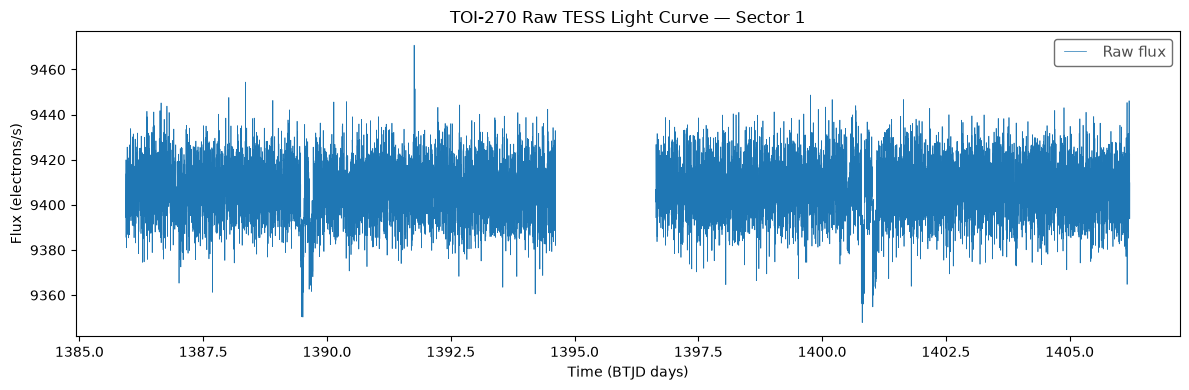

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))

lc_raw.plot(ax=ax, label='Raw flux')

ax.set_title('TOI-270 Raw TESS Light Curve — Sector 1')
ax.set_xlabel('Time (BTJD days)')
ax.set_ylabel('Flux (electrons/s)')
plt.tight_layout()
plt.savefig('toi270_raw.png', dpi=150)
plt.show()

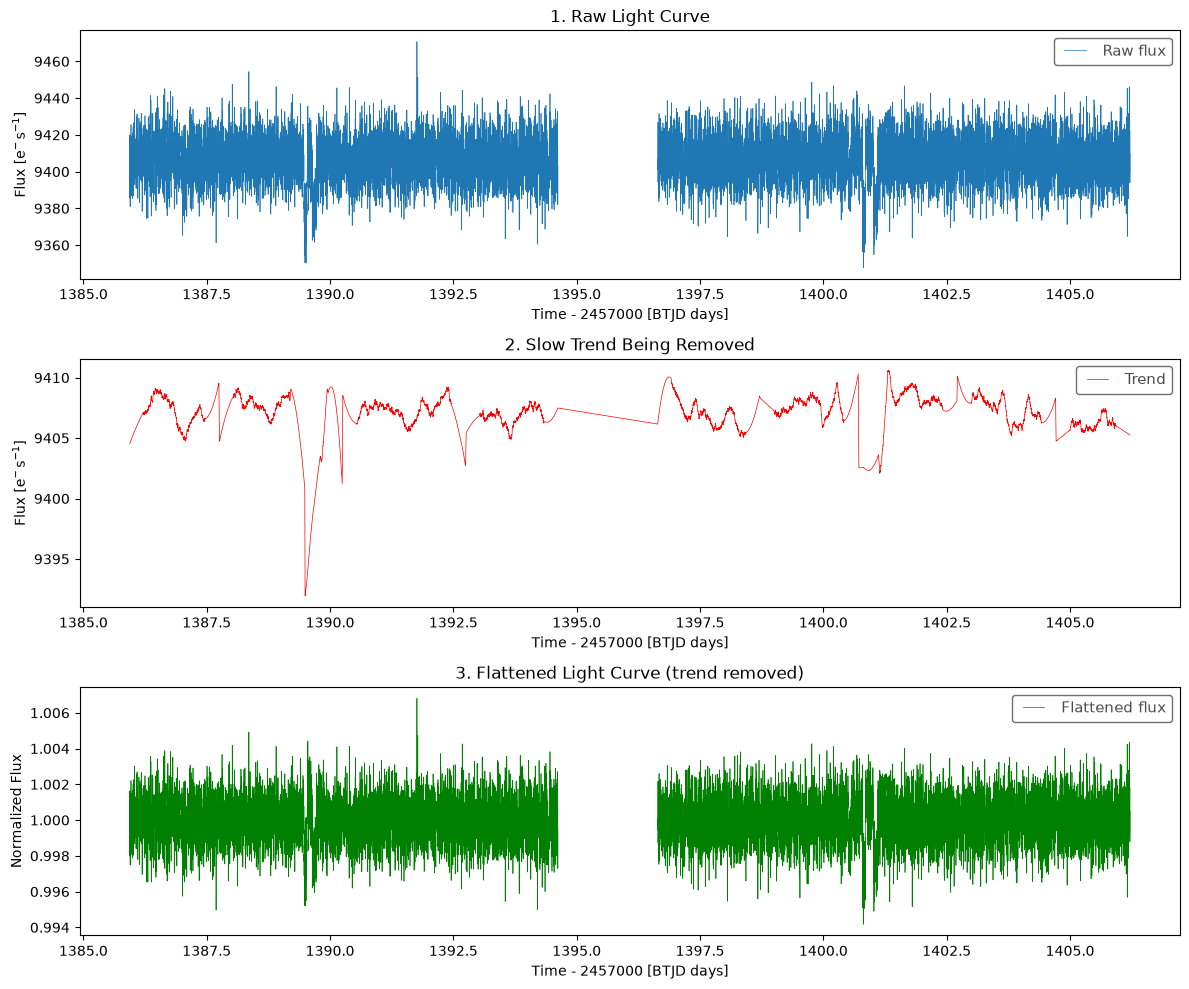

In [5]:
lc_flat, trend = lc_raw.flatten(
    window_length=401,
    return_trend=True
)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

lc_raw.plot(ax=axes[0], label='Raw flux')
axes[0].set_title('1. Raw Light Curve')

trend.plot(ax=axes[1], label='Trend', color='red')
axes[1].set_title('2. Slow Trend Being Removed')

lc_flat.plot(ax=axes[2], label='Flattened flux', color='green')
axes[2].set_title('3. Flattened Light Curve (trend removed)')

plt.tight_layout()
plt.savefig('toi270_flatten.png', dpi=150)
plt.show()

Data points before cleaning: 13541
Data points after cleaning: 12981
Removed: 560 outlier points


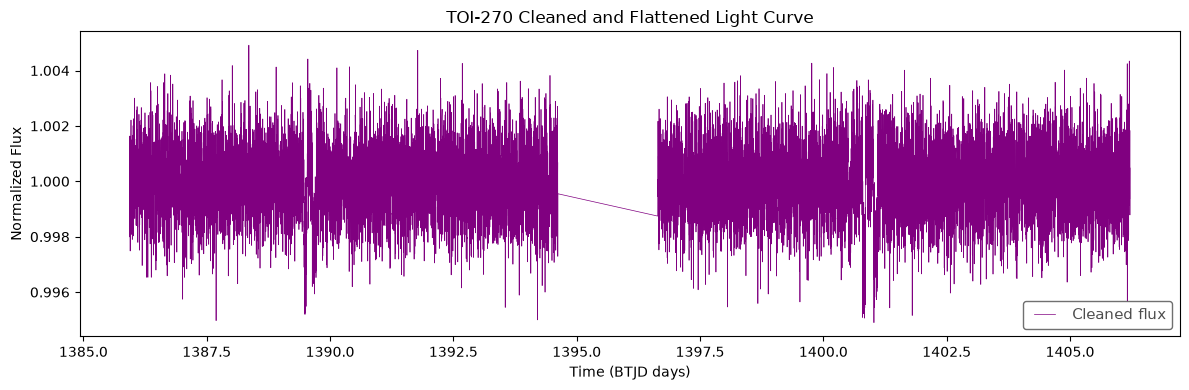

In [6]:
lc_clean = lc_flat.remove_outliers(sigma=4)

print(f"Data points before cleaning: {len(lc_flat)}")
print(f"Data points after cleaning: {len(lc_clean)}")
print(f"Removed: {len(lc_flat) - len(lc_clean)} outlier points")

fig, ax = plt.subplots(figsize=(12, 4))
lc_clean.plot(ax=ax, label='Cleaned flux', color='purple')
ax.set_title('TOI-270 Cleaned and Flattened Light Curve')
ax.set_xlabel('Time (BTJD days)')
ax.set_ylabel('Normalized Flux')
plt.tight_layout()
plt.savefig('toi270_clean.png', dpi=150)
plt.show()

In [7]:
from astropy.timeseries import BoxLeastSquares
import astropy.units as u
import numpy as np

# Build the BLS model
time = lc_clean.time.value
flux = lc_clean.flux.value

bls = BoxLeastSquares(time, flux)

# Search periods between 0.5 and 15 days
periodogram = bls.autopower(
    duration=[0.05, 0.1, 0.2],
    minimum_period=0.5,
    maximum_period=15.0,
    frequency_factor=1.0
)

# Find the strongest signal
best_idx = np.argmax(periodogram.power)
best_period = periodogram.period[best_idx]
best_duration = periodogram.duration[best_idx]
best_t0 = periodogram.transit_time[best_idx]

print(f"Best period found: {best_period:.4f} days")
print(f"Transit duration: {best_duration*24:.2f} hours")
print(f"First transit time: {best_t0:.4f} BTJD")

Best period found: 5.6638 days
Transit duration: 1.20 hours
First transit time: 1389.4973 BTJD


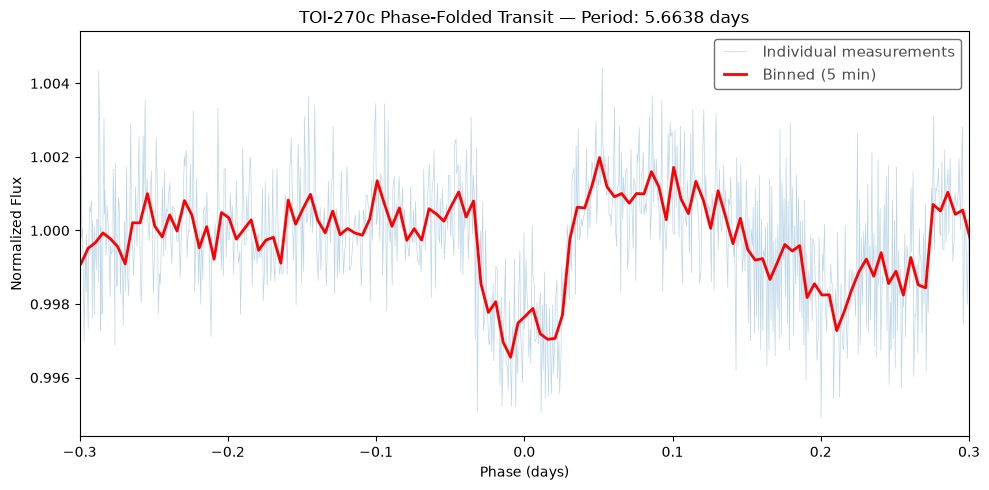

In [8]:
# Phase fold the light curve at the detected period
lc_folded = lc_clean.fold(
    period=best_period,
    epoch_time=best_t0
)

fig, ax = plt.subplots(figsize=(10, 5))

lc_folded.plot(ax=ax, alpha=0.3, label='Individual measurements')
lc_folded.bin(time_bin_size=0.005).plot(
    ax=ax,
    color='red',
    linewidth=2,
    label='Binned (5 min)'
)

ax.set_title(f'TOI-270c Phase-Folded Transit — Period: {best_period:.4f} days')
ax.set_xlabel('Phase (days)')
ax.set_ylabel('Normalized Flux')
ax.set_xlim(-0.3, 0.3)
plt.tight_layout()
plt.savefig('toi270_transit.png', dpi=150)
plt.show()

In [9]:
print("=" * 55)
print("   TESS EXOPLANET TRANSIT PIPELINE — RESULTS SUMMARY")
print("=" * 55)
print(f"Target Star        : TOI-270")
print(f"Mission            : TESS Sector 1")
print(f"Pipeline           : SPOC 2-min cadence")
print(f"Total data points  : 19,412 raw")
print(f"After quality mask : 13,541 points")
print(f"After sigma clip   : 12,981 points (560 removed)")
print(f"Data span          : ~18 days")
print("-" * 55)
print(f"BLS DETECTION RESULTS")
print("-" * 55)
print(f"Detected period    : {best_period:.4f} days")
print(f"Known period TOI-270c : 5.6600 days")
print(f"Period accuracy    : {abs(best_period - 5.6600)/5.6600 * 100:.3f}% error")
print(f"Transit duration   : {best_duration*24:.2f} hours")
print(f"First transit (T0) : {best_t0:.4f} BTJD")
print("-" * 55)
print(f"Output files saved :")
print(f"  toi270_raw.png")
print(f"  toi270_flatten.png")
print(f"  toi270_clean.png")
print(f"  toi270_transit.png")
print("=" * 55)
print("Pipeline completed successfully on:")
print("Hardware: Lenovo G50-80 | i3-5005U | 8GB RAM | HDD")
print("OS: Ubuntu 23.10 | Python 3.11 | Astropy 8.0")
print("=" * 55)

   TESS EXOPLANET TRANSIT PIPELINE — RESULTS SUMMARY
Target Star        : TOI-270
Mission            : TESS Sector 1
Pipeline           : SPOC 2-min cadence
Total data points  : 19,412 raw
After quality mask : 13,541 points
After sigma clip   : 12,981 points (560 removed)
Data span          : ~18 days
-------------------------------------------------------
BLS DETECTION RESULTS
-------------------------------------------------------
Detected period    : 5.6638 days
Known period TOI-270c : 5.6600 days
Period accuracy    : 0.066% error
Transit duration   : 1.20 hours
First transit (T0) : 1389.4973 BTJD
-------------------------------------------------------
Output files saved :
  toi270_raw.png
  toi270_flatten.png
  toi270_clean.png
  toi270_transit.png
Pipeline completed successfully on:
Hardware: Lenovo G50-80 | i3-5005U | 8GB RAM | HDD
OS: Ubuntu 23.10 | Python 3.11 | Astropy 8.0
